In [19]:
from matplotlib import pyplot as plt
import numpy as np
import os


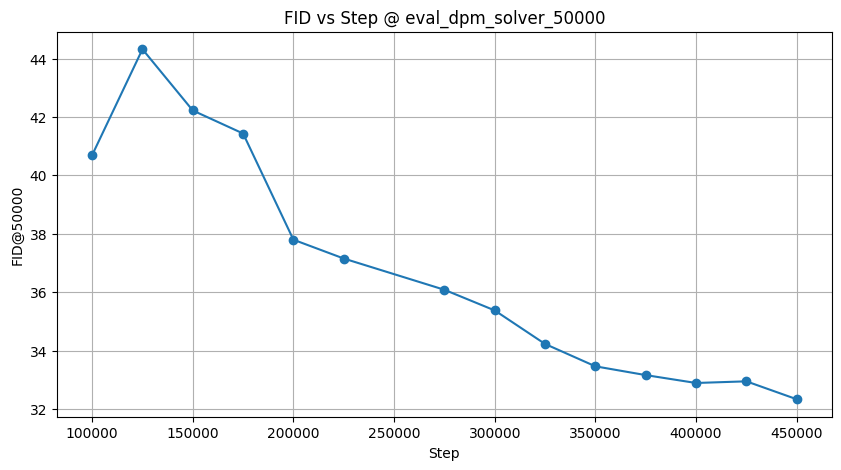

In [20]:
def plot_fid_curve(log_file: str):
    steps = []
    fids = []

    basename = os.path.basename(log_file)
    basename = basename.replace('.log', '')
    with open(log_file, 'r') as f:
        for line in f:
            if line.strip():
                parts = line.strip().split()
                step = int(parts[0].split('=')[1])
                fid = float(parts[1].split('=')[1])
                steps.append(step)
                fids.append(fid)

    plt.figure(figsize=(10, 5))  # 宽8英寸，高5英寸
    plt.plot(steps, fids, marker='o')
    plt.xlabel('Step')
    plt.ylabel('FID@50000')
    plt.title('FID vs Step @ ' + basename)
    plt.grid(True)
    plt.savefig(log_file.replace('.log', '.png'))
    plt.show()
    

plot_fid_curve('output/acdc_uncond_uvit_mid_4by4/eval_dpm_solver_50000.log')

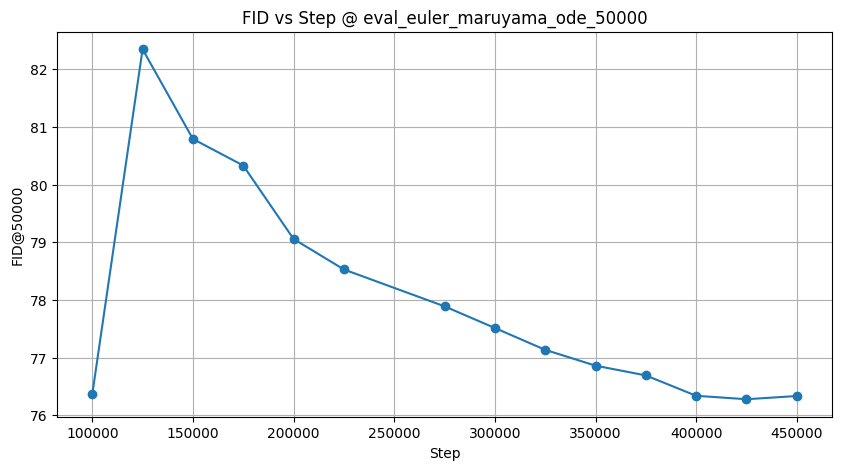

In [21]:
plot_fid_curve('output/acdc_uncond_uvit_mid_4by4/eval_euler_maruyama_ode_50000.log')

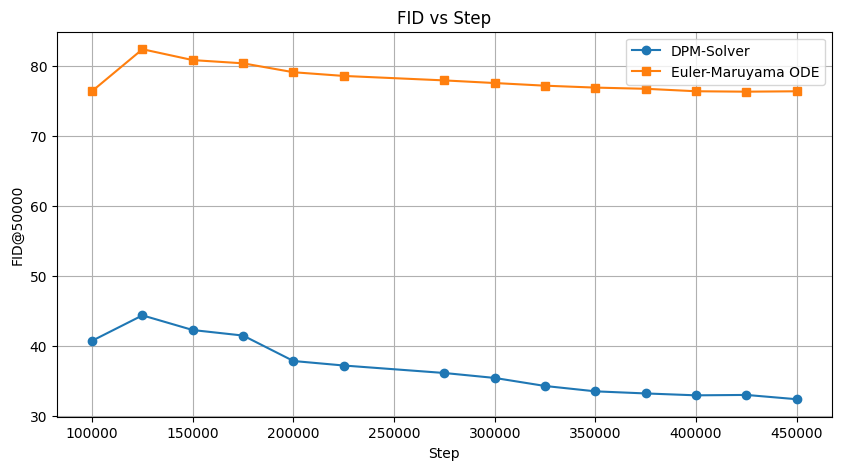

In [22]:
def plot_two_fid_curves(log_file1: str, log_file2: str, label1: str, label2: str):
    def read_log(log_file):
        steps, fids = [], []
        with open(log_file, 'r') as f:
            for line in f:
                if line.strip():
                    parts = line.strip().split()
                    step = int(parts[0].split('=')[1])
                    fid = float(parts[1].split('=')[1])
                    steps.append(step)
                    fids.append(fid)
        return steps, fids

    steps1, fids1 = read_log(log_file1)
    steps2, fids2 = read_log(log_file2)

    plt.figure(figsize=(10, 5))
    plt.plot(steps1, fids1, marker='o', label=label1 or os.path.basename(log_file1))
    plt.plot(steps2, fids2, marker='s', label=label2 or os.path.basename(log_file2))
    plt.xlabel('Step')
    plt.ylabel('FID@50000')
    plt.title('FID vs Step')
    plt.legend()
    plt.grid(True)
    plt.savefig(log_file1.replace('.log', '_vs_') + os.path.basename(log_file2).replace('.log', '.png'))
    plt.show()
    

# 用法示例
plot_two_fid_curves(
    'output/acdc_uncond_uvit_mid_4by4/eval_dpm_solver_50000.log',
    'output/acdc_uncond_uvit_mid_4by4/eval_euler_maruyama_ode_50000.log',
    label1='DPM-Solver',
    label2='Euler-Maruyama ODE'
)

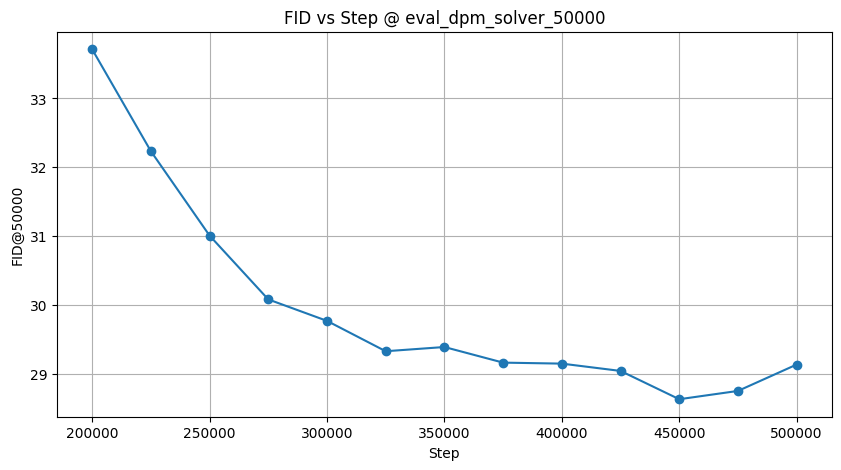

In [23]:
plot_fid_curve('output/acdc_uncond_greyscale_uvit_mid_4by4/eval_dpm_solver_50000.log')

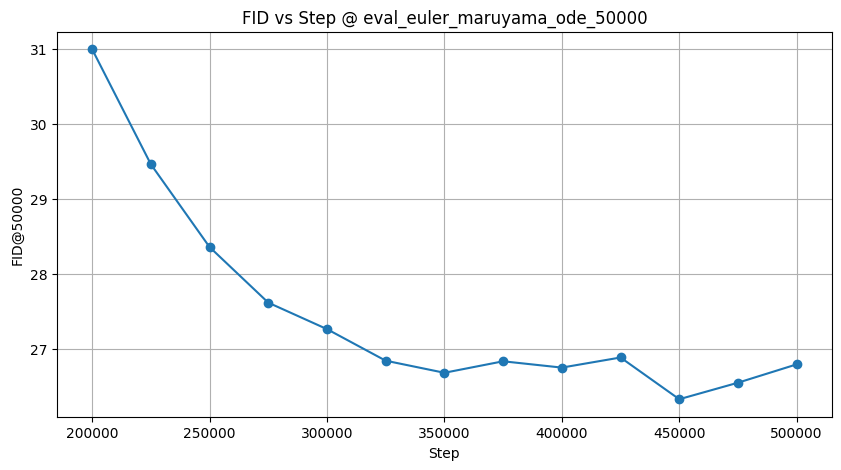

In [24]:

plot_fid_curve('output/acdc_uncond_greyscale_uvit_mid_4by4/eval_euler_maruyama_ode_50000.log')

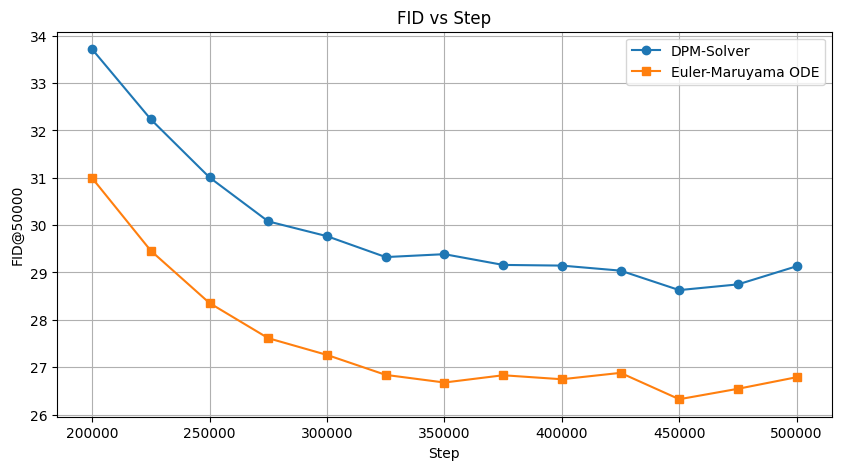

In [25]:
plot_two_fid_curves(
    'output/acdc_uncond_greyscale_uvit_mid_4by4/eval_dpm_solver_50000.log',
    'output/acdc_uncond_greyscale_uvit_mid_4by4/eval_euler_maruyama_ode_50000.log',
    label1='DPM-Solver',
    label2='Euler-Maruyama ODE'
)